### Fake News Detection Using Machine Learning and Deep Learning.

# Introduction

This notebook implements a Fake News Detection system using Natural Language Processing (NLP) techniques.

The dataset contains fake and true news articles. The text data is cleaned and preprocessed before applying machine learning and deep learning models.

The following models are developed and evaluated:

- Random Forest (Machine Learning Model)
- GRU (Deep Learning Model)

The workflow includes:
- Dataset loading and exploration.
- Text preprocessing.
- Feature extraction using TF-IDF.
- Model training.
- Model evaluation and comparison.

# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

# 2. Load the Dataset

In [2]:
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

# 3. Dataset Exploration

In [2]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


In [5]:
import pandas as pd

fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

# 4. Assign Labels to News Data

In [6]:
fake["label"] = 0
true["label"] = 1

# 5. Merge Fake and True News Dataset

In [7]:
df = pd.concat([fake, true], ignore_index=True)

# 6. Shuffle the Dataset

In [8]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [9]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [10]:
print(df.shape)

(44898, 5)


# 7. Text Preprocessing

In [11]:
df["text"] = df["text"].str.lower()

In [12]:
import string

df["text"] = df["text"].str.translate(
    str.maketrans("", "", string.punctuation)
)

In [13]:
import re

df["text"] = df["text"].apply(
    lambda x: re.sub(r"\d+", "", x)
)

In [14]:
df["text"] = df["text"].str.strip()

In [15]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,st century wire says ben stein reputable profe...,US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,washington reuters us president donald trump ...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,reuters puerto rico governor ricardo rossello...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,on monday donald trump once again embarrassed ...,News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,glasgow scotland reuters most us presidential...,politicsNews,"June 24, 2016",1


In [16]:
df.to_csv("../data/processed/clean_news.csv", index=False)

# 8. Tokenization, Stopword Removal and Lemmatization

In [17]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sahan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sahan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sahan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [19]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [20]:
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = wordpunct_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

# 9. Apply Text Preprocessing

In [21]:
df["Clean_Text"] = df["text"].apply(preprocess_text)

# 10. Display Cleaned Text

In [22]:
df[["text", "Clean_Text"]].head()

,text,Clean_Text
0,st century wire says ben stein reputable profe...,st century wire say ben stein reputable profes...
1,washington reuters us president donald trump ...,washington reuters u president donald trump re...
2,reuters puerto rico governor ricardo rossello...,reuters puerto rico governor ricardo rossello ...
3,on monday donald trump once again embarrassed ...,monday donald trump embarrassed country accide...
4,glasgow scotland reuters most us presidential...,glasgow scotland reuters u presidential candid...


# 11. Exploratory Data Analysis (EDA)

In [24]:
print("Dataset Shape:", df.shape)

Dataset Shape: (44898, 6)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       44898 non-null  object
 1   text        44898 non-null  object
 2   subject     44898 non-null  object
 3   date        44898 non-null  object
 4   label       44898 non-null  int64 
 5   Clean_Text  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB


In [26]:
print(df.isnull().sum())

title         0
text          0
subject       0
date          0
label         0
Clean_Text    0
dtype: int64


In [27]:
print(df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


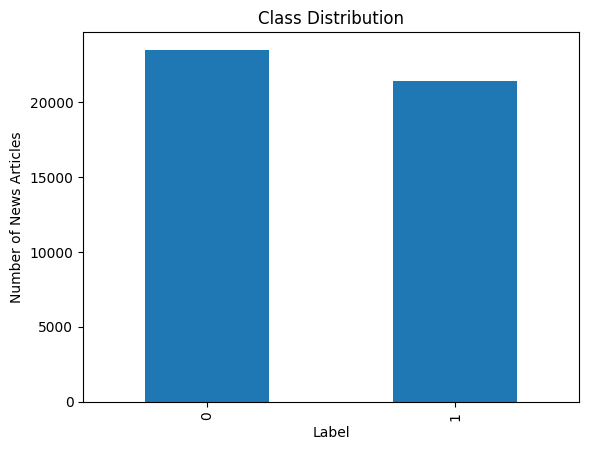

In [28]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of News Articles")

plt.show()

# 12. TF-IDF Feature Extraction

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Text"])

y = df["label"]

print(X.shape)

(44898, 5000)


# 13. Split Dataset into Training and Testing Sets

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 14. Random Forest Model Training

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [35]:
y_pred = rf.predict(X_test)

# 15. Random Forest Model Evaluation

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9968819599109131


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4710
           1       1.00      1.00      1.00      4270

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4697   13]
 [  15 4255]]


# 16. Tokenization and Padding for GRU

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [40]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df["Clean_Text"])

In [41]:
sequences = tokenizer.texts_to_sequences(df["Clean_Text"])

In [42]:
X_dl = pad_sequences(sequences, maxlen=200)

In [43]:
y_dl = df["label"]

In [44]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42
)

# 17. Build GRU Model

In [45]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=200))

model.add(GRU(64))

model.add(Dense(1, activation="sigmoid"))

c:\Users\sahan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [46]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
print(df.shape)

(44898, 6)


In [49]:
print(X_train_dl.shape)

(35918, 200)


In [50]:
print(y_train_dl.shape)

(35918,)


In [51]:
print(X_test_dl.shape)

(8980, 200)


# 18. Train GRU Model

In [52]:
history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 66s 137ms/step - accuracy: 0.9485 - loss: 0.1428 - val_accuracy: 0.9596 - val_loss: 0.1142
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 133ms/step - accuracy: 0.9800 - loss: 0.0613 - val_accuracy: 0.9823 - val_loss: 0.0526
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 61s 136ms/step - accuracy: 0.9802 - loss: 0.0639 - val_accuracy: 0.9780 - val_loss: 0.0584
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 59s 132ms/step - accuracy: 0.9905 - loss: 0.0292 - val_accuracy: 0.9889 - val_loss: 0.0349
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 59s 133ms/step - accuracy: 0.9856 - loss: 0.0440 - val_accuracy: 0.9916 - val_loss: 0.0273


# 19. GRU Model Evaluation

In [53]:
loss, accuracy = model.evaluate(X_test_dl, y_test_dl)

print("Test Accuracy:", accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9901 - loss: 0.0334
Test Accuracy: 0.9900890588760376


In [54]:
y_pred_prob = model.predict(X_test_dl)

281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step


In [55]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test_dl, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4710
           1       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_dl, y_pred)

print(cm)

[[4671   39]
 [  50 4220]]


# 20. Model Comparison

In [58]:
import pandas as pd

comparison = {
    "Model": ["Random Forest", "GRU"],
    "Accuracy": [0.9969, 0.99]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy
0,Random Forest,0.9969
1,GRU,0.9900
